In [ ]:
%load_ext autoreload
%autoreload 2


In [ ]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from medmnist import PathMNIST
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import torch

# Test hue transfromation

In [ ]:
pmnist_train = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transforms.ToTensor())
pmnist_test = PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transforms.ToTensor())
x = pmnist_train[0][0].float()   

In [ ]:
class RGBToHSV:
    """Custom transform: convert RGB tensor [C,H,W] in [0,1] to HSV [C,H,W]"""
    def __call__(self, img_tensor):
        # img_tensor: [C,H,W] in [0,1]
        img_np = img_tensor.permute(1, 2, 0).numpy()  # [H,W,C]
        hsv_np = rgb_to_hsv(img_np)                    # [H,W,C], hue in [0,1]
        hsv_tensor = torch.tensor(hsv_np).permute(2, 0, 1)  # back to [C,H,W]
        return hsv_tensor

In [ ]:
transform_hsv = transforms.Compose([
    transforms.ToTensor(),
    RGBToHSV()
])

pmnist_train_hsv = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transform_hsv)
x_hsv = pmnist_train_hsv[0][0].float()

# Test hue group

In [ ]:
import escnn
import escnn.nn as enn
from escnn import gspaces
from escnn import group
import torch.nn as nn

In [7]:
model = enn.HuePhaseLiftGroupConv2D(
    H=4,
    hidden_fields=1,
    out_fields=1
    )

{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}
Size: <bound method Group.order of C4>
{'irrep_0': C1|[irrep_0]:1}


In [8]:
x_tr, z, y, g = model(x_hsv.unsqueeze(0))

Encoded shape4: torch.Size([1, 4, 28, 28])


In [12]:
x_hsv.shape, x_tr.shape, z.shape, y.shape

(torch.Size([3, 28, 28]),
 torch.Size([1, 4, 28, 28]),
 torch.Size([1, 4, 28, 28]),
 torch.Size([1, 4, 28, 28]))

In [ ]:
# dummy equivariant CNN
from escnn import gspaces
import escnn.nn as enn

class DummyEqCNN(nn.Module):
    def __init__(self, keep_dim=False):
        super().__init__()
        self.N = 4
        self.r2_act = gspaces.rot2dOnR2(self.N)
        if keep_dim:
            self.S = self.r2_act.fibergroup.order()
        else:
            self.S = 1
        print("S:", self.S)
        self.in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.out_type = enn.FieldType(self.r2_act, [self.r2_act.regular_repr] * (64 // self.S))
        self.conv = enn.R2Conv(self.in_type, self.out_type, kernel_size=3, padding=1, bias=False)

        self.out_type2 = enn.FieldType(self.r2_act, [self.r2_act.regular_repr]*(128 // self.S))

        self.conv2 = enn.R2Conv(self.out_type, self.out_type2, kernel_size=3, padding=1, bias=False)
        self.conv3 = enn.R2Conv(self.out_type2, self.out_type2, kernel_size=3, padding=1, bias=False)
        self.conv4 = enn.R2Conv(self.out_type2, self.out_type2, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        x = enn.GeometricTensor(x, self.in_type)
        x = self.conv(x)
        print("After conv1:", x.tensor.shape)
        x = self.conv2(x)
        print("After conv2:", x.tensor.shape)
        x = self.conv3(x)
        print("After conv3:", x.tensor.shape)
        x = self.conv4(x)
        print("After conv4:", x.tensor.shape)
        return x
    
model_eq_cnn = DummyEqCNN(keep_dim=True).to(device)
count_trainable_parameters(model_eq_cnn)
dummy_input = torch.zeros(1, 1, 5, 5).to(device)  # 100x100 spatial size
y = model_eq_cnn(dummy_input)
#summary(model_eq_cnn.to('cuda'), (1, 1, 5, 5))


In [40]:
from matplotlib.colors import hsv_to_rgb

Text(0.5, 1.0, 'Modified HSV to RGB')

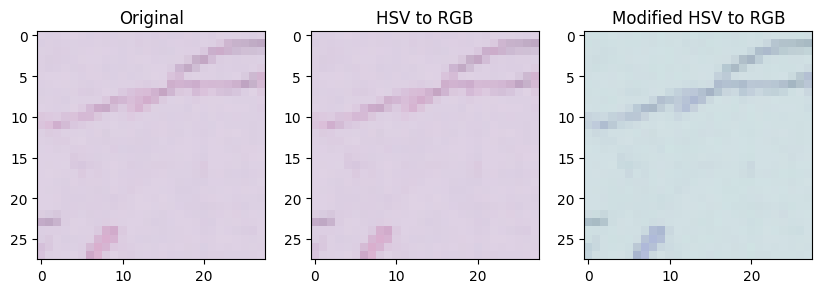

In [46]:
x_hsv2 = x_hsv.clone()
x_hsv2[0,:, :] = x_hsv[0,:, :] - 0.25

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

x_rgb = hsv_to_rgb(x_hsv.permute(1, 2, 0))
x_rgb2 = hsv_to_rgb(x_hsv2.permute(1, 2, 0))

ax[0].imshow(x.permute(1, 2, 0))
ax[0].set_title("Original")

ax[1].imshow(x_rgb)
ax[1].set_title("HSV to RGB")
ax[2].imshow(x_rgb2)
ax[2].set_title("Modified HSV to RGB")

In [10]:
x_tr, z, y1, g = model(x_hsv.unsqueeze(0))
x_tr2, z2, y2, g2 = model(x_hsv2.unsqueeze(0))



Encoded shape4: torch.Size([1, 4, 28, 28])


NameError: name 'x_hsv2' is not defined

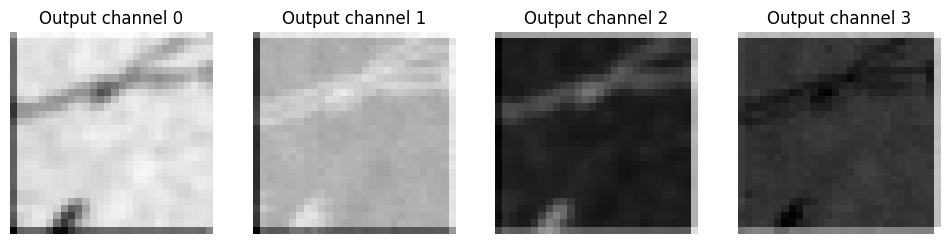

In [30]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    ax[i].imshow(z.tensor[0, i].detach().numpy(), cmap='gray')
    ax[i].set_title(f'Output channel {i}')
    ax[i].axis('off')

In [18]:
y.tensor[0, 0].shape

torch.Size([28, 28])

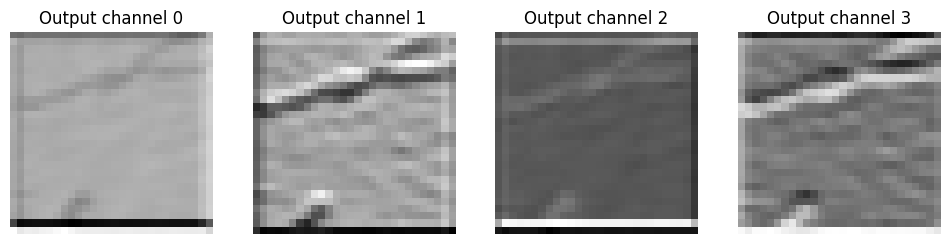

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    ax[i].imshow(y.tensor[0, i].detach().numpy(), cmap='gray')
    ax[i].set_title(f'Output channel {i}')
    ax[i].axis('off')

 output shape: torch.Size([1, 4, 28, 28])


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

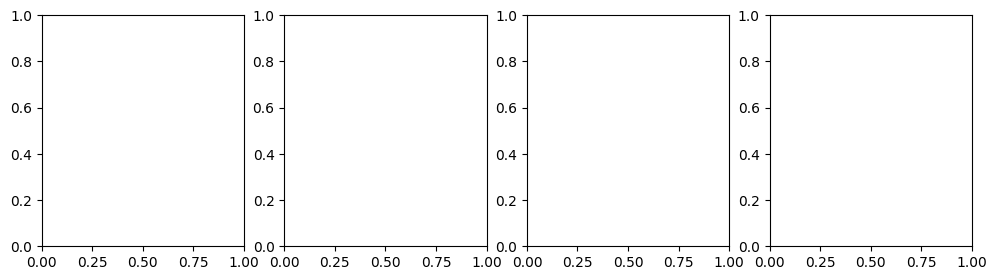

In [16]:
from escnn import gspaces
r2_act = gspaces.hueOnR2(4)
transformations = r2_act.fibergroup.elements

fig, ax = plt.subplots(1, len(transformations), figsize=(3 * len(transformations), 3))

for i, tr in enumerate(transformations):
    out1 = x_tr.transform(tr).tensor.detach().cpu()
    print(f" output shape: {out1.shape}")  

    ax[i].imshow(out1.permute(1,2,0).numpy())
    ax[i].set_title(f"transform: {tr.name}")
    ax[i].axis("off")


0: True
1: False
2: False
3: False
4: False
5: False
6: False
7: False


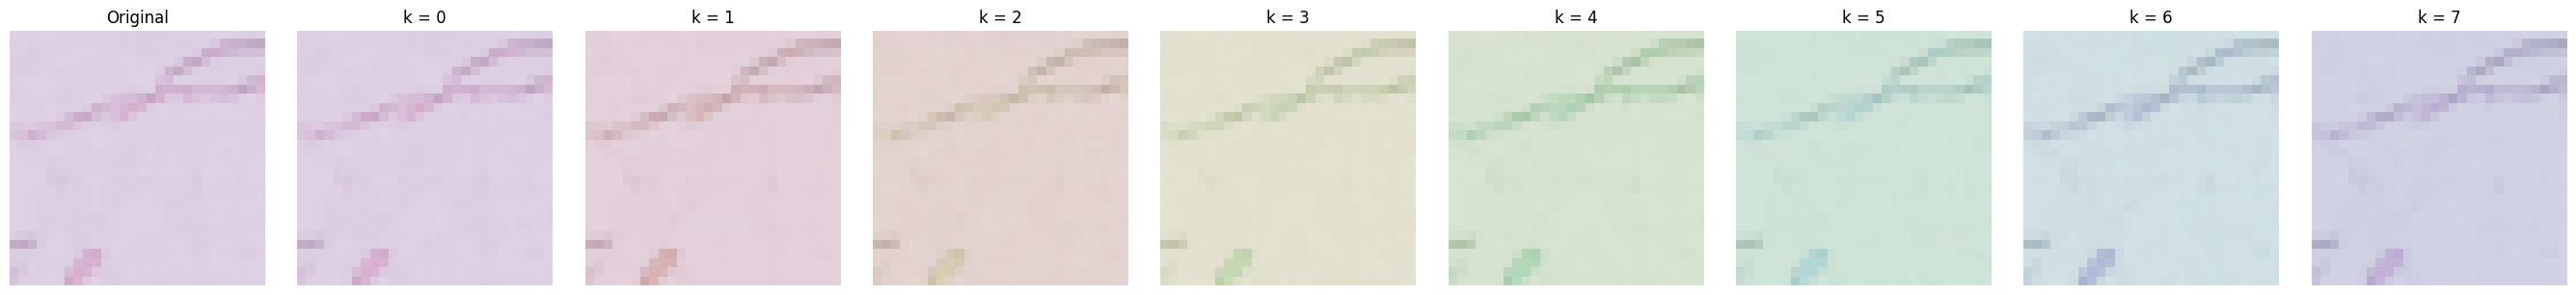

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from escnn import gspaces
import escnn.nn as enn

# x_hsv must be [3, H, W], hue in [0,1]
x = x_hsv.detach().float().cpu().clone()
# x[0] = torch.remainder(x[0], 1.0)
# x[1:] = x[1:].clamp(0.0, 1.0)

H_group = 8
act = gspaces.hueOnR2(H_group)  # hue-only group C4 on R2 (no spatial action)

# Encode hue as phase [cos(2πh), sin(2πh)] + keep S,V
theta = 2.0 * np.pi * x[0]
x_phase = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)

in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])
gx = enn.GeometricTensor(x_phase, in_type)

def decode_to_rgb(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    s = gxk.tensor[0, 2].clip(0.0, 1.0)
    v = gxk.tensor[0, 3].clip(0.0, 1.0)
    hsv = torch.stack([h, s, v], dim=-1).numpy()
    return hsv_to_rgb(hsv)

# Plot original + all 4 group elements
fig, ax = plt.subplots(1, H_group + 1, figsize=(3 * (H_group + 1), 3))

ax[0].imshow(hsv_to_rgb(x.permute(1, 2, 0).numpy()))
ax[0].set_title("Original")
ax[0].axis("off")

for k in range(H_group):
    gk = act.fibergroup.element(k)
    gxk = gx.transform(gk)
    ax[k + 1].imshow(decode_to_rgb(gxk))
    ax[k + 1].set_title(f"k = {k}")
    ax[k + 1].axis("off")
    print(f'{k}: {np.allclose(hsv_to_rgb(x.permute(1, 2, 0).numpy()), decode_to_rgb(gxk))}')

plt.tight_layout()
plt.show()


In [59]:
import torch

def rescale(x, a=0.0, b=1.0):
    x_min = x.min()
    x_max = x.max()
    return a + (x - x_min) * (b - a) / (x_max - x_min)

After conv: torch.Size([1, 4, 26, 26])


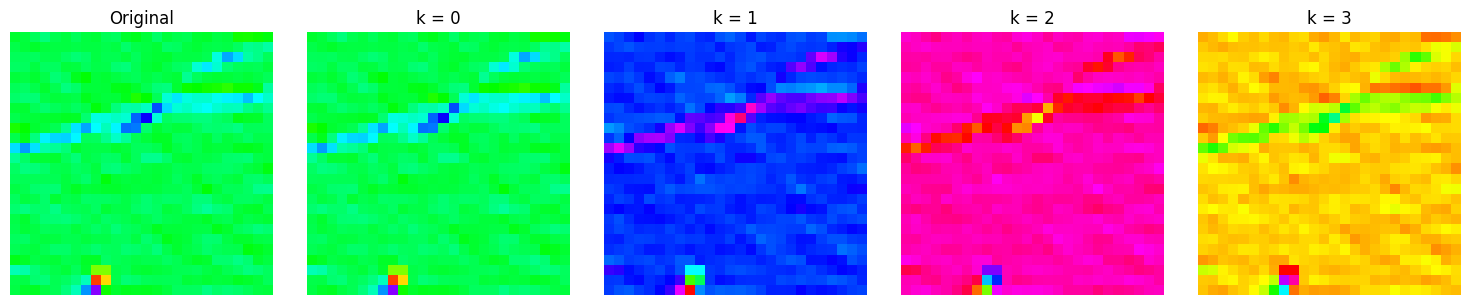

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from escnn import gspaces
import escnn.nn as enn

# x_hsv must be [3, H, W], hue in [0,1]
x = x_hsv.detach().float().cpu().clone()
# x[0] = torch.remainder(x[0], 1.0)
# x[1:] = x[1:].clamp(0.0, 1.0)

H_group = 4
act = gspaces.hueOnR2(H_group)  # hue-only group C4 on R2 (no spatial action)

# Encode hue as phase [cos(2πh), sin(2πh)] + keep S,V
theta = 2.0 * np.pi * x[0]
x_phase = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)

in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])
gx = enn.GeometricTensor(x_phase, in_type)
out_type = enn.FieldType(act, [act.regular_repr])
# apply conv layer
conv = enn.R2Conv(in_type, in_type, kernel_size=3, padding=0, bias=False)
with torch.no_grad():
    gx = conv(gx)
print("After conv:", gx.tensor.shape)


def decode_to_rgb(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    s = gxk.tensor[0, 2].clip(0.0, 1.0)
    v = gxk.tensor[0, 3].clip(0.0, 1.0)
    hsv = torch.stack([h, s, v], dim=-1).numpy()
    return hsv_to_rgb(hsv)

# Plot original + all 4 group elements
fig, ax = plt.subplots(1, H_group + 1, figsize=(3 * (H_group + 1), 3))

ax[0].imshow(decode_to_rgb(gx))
ax[0].set_title("Original")
ax[0].axis("off")

for k in range(H_group):
    gk = act.fibergroup.element(k)
    gxk = gx.transform(gk)
    ax[k + 1].imshow(decode_to_rgb(gxk))
    ax[k + 1].set_title(f"k = {k}")
    ax[k + 1].axis("off")
    #print(f'{k}: {np.allclose(hsv_to_rgb(x.permute(1, 2, 0).numpy()), decode_to_rgb(gxk))}')

plt.tight_layout()
plt.show()

Equivariance MAE: 4.472e-08
Best channel roll: 1, MAE: 0.000e+00


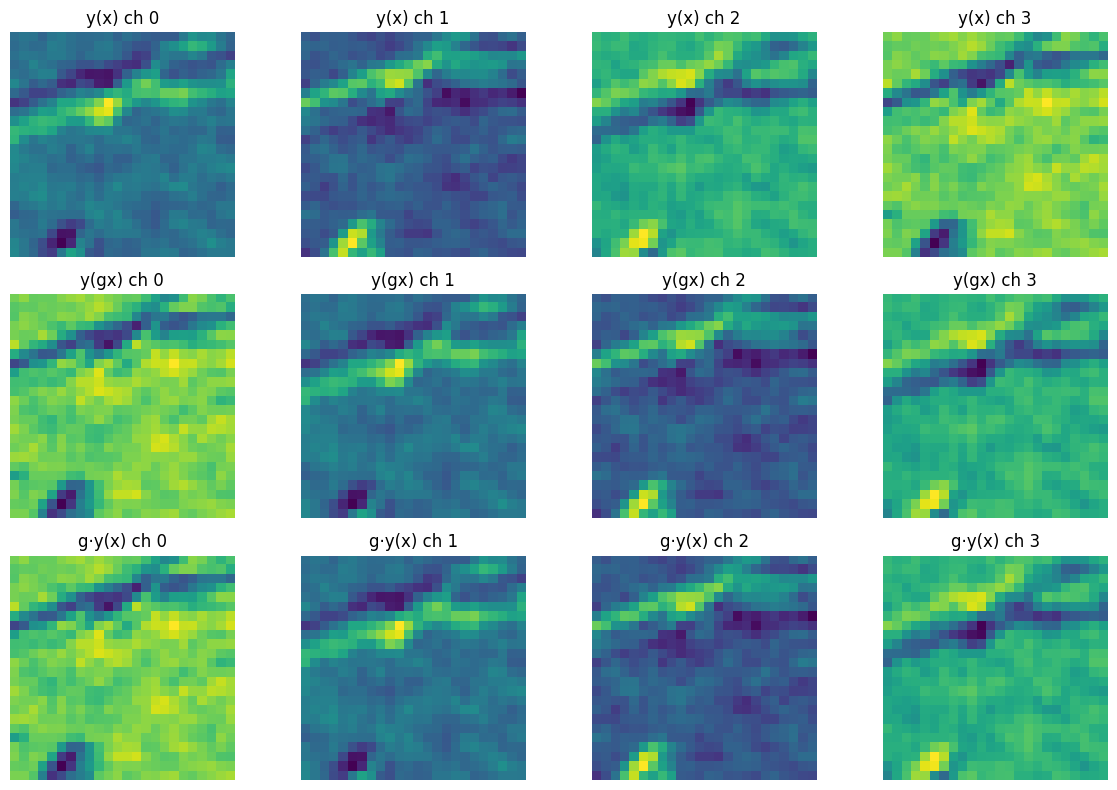

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)

with torch.no_grad():
    y = conv(gx)               # y(x)
    y_from_gx = conv(gx.transform(g))   # y(gx)
    gy = y.transform(g)        # g y(x)

# equivariance check: y(gx) == g y(x)
eq_err = (y_from_gx.tensor - gy.tensor).abs().mean().item()
print(f"Equivariance MAE: {eq_err:.3e}")

# check which cyclic roll corresponds to transform on regular channels
src = y.tensor[0]      # [4,H,W]
tgt = gy.tensor[0]     # [4,H,W]
errs = [ (torch.roll(src, shifts=r, dims=0) - tgt).abs().mean().item() for r in range(H) ]
best_roll = int(np.argmin(errs))
print(f"Best channel roll: {best_roll}, MAE: {errs[best_roll]:.3e}")

# ----- plot channels -----
fig, ax = plt.subplots(3, H, figsize=(3*H, 8))
for i in range(H):
    ax[0, i].imshow(y.tensor[0, i].detach().cpu(), cmap="viridis")
    ax[0, i].set_title(f"y(x) ch {i}")
    ax[0, i].axis("off")

    ax[1, i].imshow(y_from_gx.tensor[0, i].detach().cpu(), cmap="viridis")
    ax[1, i].set_title(f"y(gx) ch {i}")
    ax[1, i].axis("off")

    ax[2, i].imshow(gy.tensor[0, i].detach().cpu(), cmap="viridis")
    ax[2, i].set_title(f"g·y(x) ch {i}")
    ax[2, i].axis("off")

plt.tight_layout()
plt.show()


Shape gx: torch.Size([1, 4, 28, 28])
Shape y: torch.Size([1, 6, 26, 26])
Transform: 0[2pi/4], out1 shape: torch.Size([1, 6, 26, 26]), out2 shape: torch.Size([1, 6, 26, 26])
Transform: 0[2pi/4], Equivariance MAE: 0.000e+00
Transform: 1[2pi/4], out1 shape: torch.Size([1, 6, 26, 26]), out2 shape: torch.Size([1, 6, 26, 26])
Transform: 1[2pi/4], Equivariance MAE: 2.812e-08
Transform: 2[2pi/4], out1 shape: torch.Size([1, 6, 26, 26]), out2 shape: torch.Size([1, 6, 26, 26])
Transform: 2[2pi/4], Equivariance MAE: 4.688e-09
Transform: 3[2pi/4], out1 shape: torch.Size([1, 6, 26, 26]), out2 shape: torch.Size([1, 6, 26, 26])
Transform: 3[2pi/4], Equivariance MAE: 2.807e-08


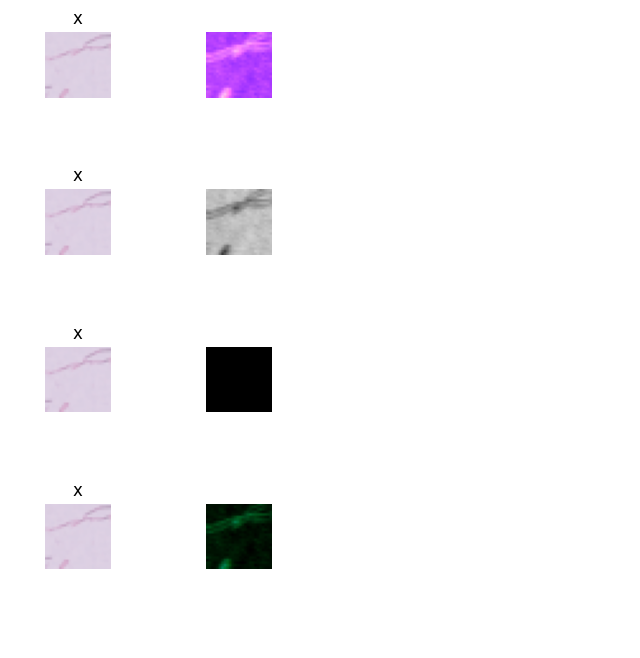

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
y = conv(gx) 
transformations = act.fibergroup.elements
print('Shape gx:', gx.tensor.shape)
print('Shape y:', y.tensor.shape)

fig, ax = plt.subplots(8, 4, figsize=(8, 8))

idx = [0, 2, 4, 6]
for i, tr in zip(idx, transformations):
    with torch.no_grad():
        out1 = conv(gx.transform(tr))
        out2 = y.transform(tr)
        print(f"Transform: {tr}, out1 shape: {out1.tensor.shape}, out2 shape: {out2.tensor.shape}")

        err = (out1.tensor - out2.tensor).abs().mean().item()

    print(f"Transform: {tr}, Equivariance MAE: {err:.3e}")

    ax[i, 0].imshow(decode_to_rgb(gx))
    ax[i, 0].set_title('x')

    ax[i, 1].imshow(decode_to_rgb(out1))


for ax in ax.flatten():
    ax.axis('off')


In [ ]:
def decode_to_rgb2(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    hsv = torch.stack([h], dim=-1).numpy()
    return hsv

In [143]:
def decode_to_rgb3(gxk, s=1.0, v=1.0):
    # constant sat and val
    h, w = gxk.tensor[0,0,:].shape
    hsv = torch.zeros((h, w, 3))  # [H,W,3]

    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    hsv[..., 0] = h
    hsv[..., 1] = s  # constant saturation
    hsv[..., 2] = v # constant value

    rgb = hsv_to_rgb(hsv)
    return rgb

Shape gx: torch.Size([1, 4, 28, 28])
Shape y: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], Equivariance MAE: 0.000e+00
<class 'numpy.ndarray'>
Transform: 1[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 1[2pi/4], Equivariance MAE: 3.561e-08
<class 'numpy.ndarray'>
Transform: 2[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 2[2pi/4], Equivariance MAE: 1.695e-08
<class 'numpy.ndarray'>
Transform: 3[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 3[2pi/4], Equivariance MAE: 3.584e-08
<class 'numpy.ndarray'>


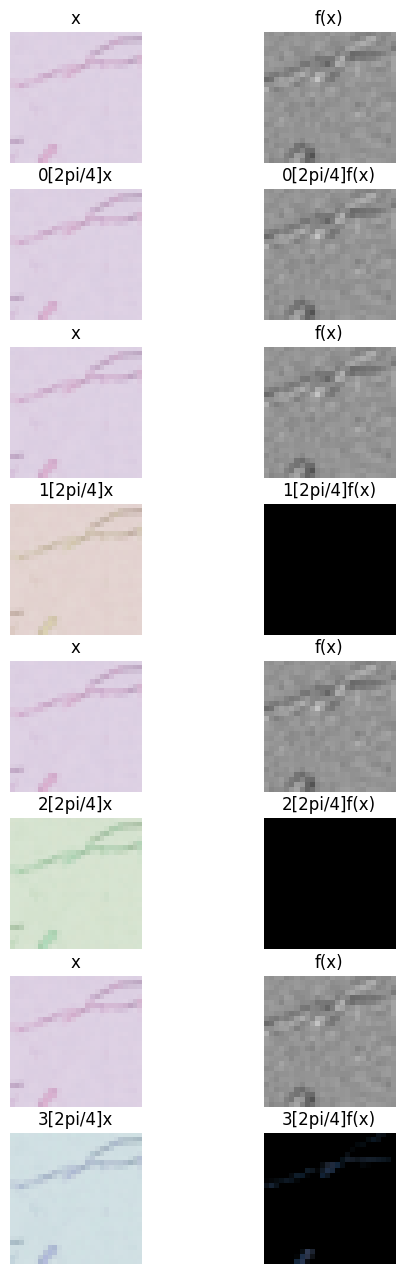

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
with torch.no_grad():
    y = conv(gx) 
transformations = act.fibergroup.elements
print('Shape gx:', gx.tensor.shape)
print('Shape y:', y.tensor.shape)

fig, ax = plt.subplots(8, 2, figsize=(6, 16))

idx = [0, 2, 4, 6]
for i, tr in zip(idx, transformations):
    with torch.no_grad():
        out1 = conv(gx.transform(tr))
        out2 = y.transform(tr)
        print(f"Transform: {tr}, out1 shape: {out1.tensor.shape}, out2 shape: {out2.tensor.shape}")

        err = (out1.tensor - out2.tensor).abs().mean().item()

    print(f"Transform: {tr}, Equivariance MAE: {err:.3e}")
    print(type(decode_to_rgb(gx)))

    ax[i, 0].imshow(decode_to_rgb(gx))
    ax[i, 0].set_title('x')

    ax[i, 1].imshow(decode_to_rgb(y))
    ax[i, 1].set_title('f(x)')

    ax[i+1, 1].imshow(decode_to_rgb(out2))
    ax[i+1, 1].set_title(f'{tr}f(x)')

    ax[i+1, 0].imshow(decode_to_rgb(gx.transform(tr)))
    ax[i+1, 0].set_title(f'{tr}x')

for ax in ax.flatten():
    ax.axis('off')


torch.Size([26, 26])
Channel 0 diff: 5.079e-08
Channel 1 diff: 4.444e-08
Channel 2 diff: 4.596e-08
Channel 3 diff: 4.656e-08


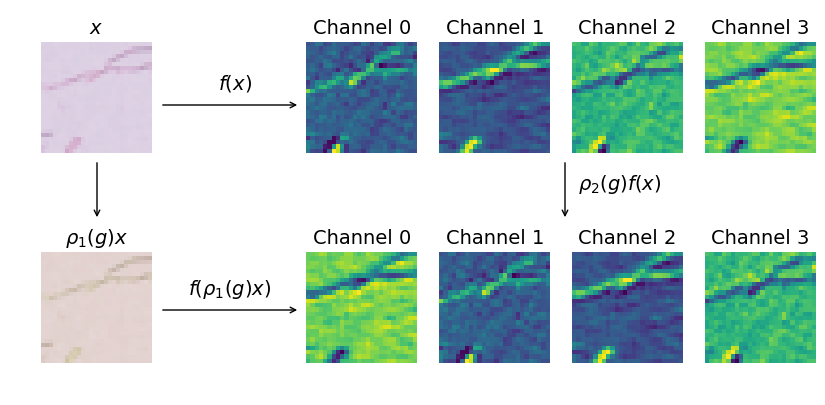

In [95]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
with torch.no_grad():
    y = conv(gx) 
transformations = act.fibergroup.elements
print(y.tensor.squeeze(0)[0].shape)
def decode_to_rgb(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    s = gxk.tensor[0, 2].clip(0.0, 1.0)
    v = gxk.tensor[0, 3].clip(0.0, 1.0)
    hsv = torch.stack([h, s, v], dim=-1).numpy()
    return hsv_to_rgb(hsv)

fig, ax = plt.subplots(2, 6, figsize=(10, 5))

# with torch.no_grad():
#     out1 = conv(gx.transform(1))
#     out2 = y.transform(1)

ax[0, 0].imshow(decode_to_rgb(gx))
ax[0, 0].set_title('$x$', fontsize=14)

for i in range(4):
    ax[0, i+2].imshow(y.tensor.squeeze(0)[i])
    ax[0, i+2].set_title(f'Channel {i}', fontsize=14)

x_g = gx.transform(transformations[1])
ax[1, 0].imshow(decode_to_rgb(x_g))
ax[1, 0].set_title(r'$\rho_1(g)x$', fontsize=14)

with torch.no_grad():
    y_g = conv(x_g)
for i in range(4):
    ax[1, i+2].imshow(y_g.tensor.squeeze(0)[i])
    ax[1, i+2].set_title(f'Channel {i}', fontsize=14)

    diff = (y_g.tensor.squeeze(0)[i] - y.tensor.squeeze(0)[i-1 %4]).abs().mean().item()
    print(f'Channel {i} diff: {diff:.3e}')

# f(x) 1
ax[0, 1].annotate(
    '',
    xy=(0.3, 0.6),   # target subplot center
    xytext=(0.16, 0.6),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[0, 1].annotate(
    '$f(x)$',
    xy=(0.235, 0.6),
    xytext=(0.235, 0.63),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

# f(x) 2
ax[1, 1].annotate(
    '',
    xy=(0.3, 0.19),   # target subplot center
    xytext=(0.16, 0.19),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[1, 1].annotate(
    r'$f\left(\rho_1(g)x\right)$',
    xy=(0.23, 0.19),
    xytext=(0.23, 0.22),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

# g 1
ax[1, 1].annotate(
    '',
    xy=(0.097, 0.37),
    xytext=(0.097, 0.49),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)

# g2
ax[1, 1].annotate(
    '',
    xy=(0.565, 0.37),
    xytext=(0.565, 0.49),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[1, 1].annotate(
    r'$\rho_2(g) f(x)$',
    xy=(0.62, 0.43),
    xytext=(0.62, 0.43),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

for ax in ax.flatten():
    ax.axis('off')


torch.Size([26, 26])
Channel 0 diff: 2.780e-08
Channel 1 diff: 4.678e-08
Channel 2 diff: 1.847e-08
Channel 3 diff: 4.783e-08


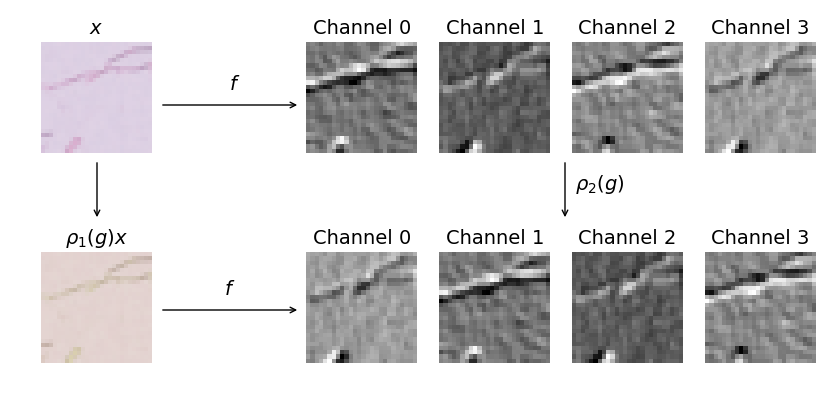

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn
from matplotlib.cm import ScalarMappable

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
with torch.no_grad():
    y = conv(gx) 

transformations = act.fibergroup.elements
min, max = y_g.tensor.min().item(), y_g.tensor.max().item()

def decode_to_rgb(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.remainder(torch.atan2(p[1], p[0]) / (2.0 * np.pi), 1.0)
    s = gxk.tensor[0, 2].clip(0.0, 1.0)
    v = gxk.tensor[0, 3].clip(0.0, 1.0)
    hsv = torch.stack([h, s, v], dim=-1).numpy()
    return hsv_to_rgb(hsv)

fig, ax = plt.subplots(2, 6, figsize=(10, 5))

ax[0, 0].imshow(decode_to_rgb(gx))
ax[0, 0].set_title('$x$', fontsize=14)

for i in range(4):
    ax[0, i+2].imshow(y.tensor.squeeze(0)[i], cmap='viridis', vmin=min, vmax=max)
    ax[0, i+2].set_title(f'Channel {i}', fontsize=14)

x_g = gx.transform(transformations[1])
ax[1, 0].imshow(decode_to_rgb(x_g))
ax[1, 0].set_title(r'$\rho_1(g) x$', fontsize=14)

with torch.no_grad():
    y_g = conv(x_g)

for i in range(4):
    ax[1, i+2].imshow(y_g.tensor.squeeze(0)[i], cmap='viridis', vmin=min, vmax=max)
    ax[1, i+2].set_title(f'Channel {i}', fontsize=14)

    diff = (y_g.tensor.squeeze(0)[i] - y.tensor.squeeze(0)[i-1 %4]).abs().mean().item()
    print(f'Channel {i} diff: {diff:.3e}')

# add colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin=min, vmax=max))
sm.set_array([])

# Add colorbar spanning all subplots in last column
fig.colorbar(sm, ax=ax[:, -1], location='right', fraction=0.05, pad=0.05)

# f(x) 1
ax[0, 1].annotate(
    '',
    xy=(0.3, 0.6),   # target subplot center
    xytext=(0.16, 0.6),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[0, 1].annotate(
    '$f$',
    xy=(0.235, 0.6),
    xytext=(0.235, 0.63),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

# f(x) 2
ax[1, 1].annotate(
    '',
    xy=(0.3, 0.19),   # target subplot center
    xytext=(0.16, 0.19),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[1, 1].annotate(
    r'$f$',
    xy=(0.23, 0.19),
    xytext=(0.23, 0.22),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

# g 1
ax[1, 1].annotate(
    '',
    xy=(0.097, 0.37),
    xytext=(0.097, 0.49),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)

# g2
ax[1, 1].annotate(
    '',
    xy=(0.565, 0.37),
    xytext=(0.565, 0.49),  # source subplot center
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1)
)
ax[1, 1].annotate(
    r'$\rho_2(g)$',
    xy=(0.6, 0.43),
    xytext=(0.6, 0.43),   # slightly above arrow center
    xycoords='figure fraction',
    textcoords='figure fraction',
    ha='center',
    fontsize=14
)

for ax in ax.flatten():
    ax.axis('off')


Shape gx: torch.Size([1, 2, 28, 28])
Shape y: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], Equivariance MAE: 0.000e+00
Transform: 1[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 1[2pi/4], Equivariance MAE: 2.349e-08
Transform: 2[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 2[2pi/4], Equivariance MAE: 0.000e+00
Transform: 3[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 3[2pi/4], Equivariance MAE: 2.349e-08


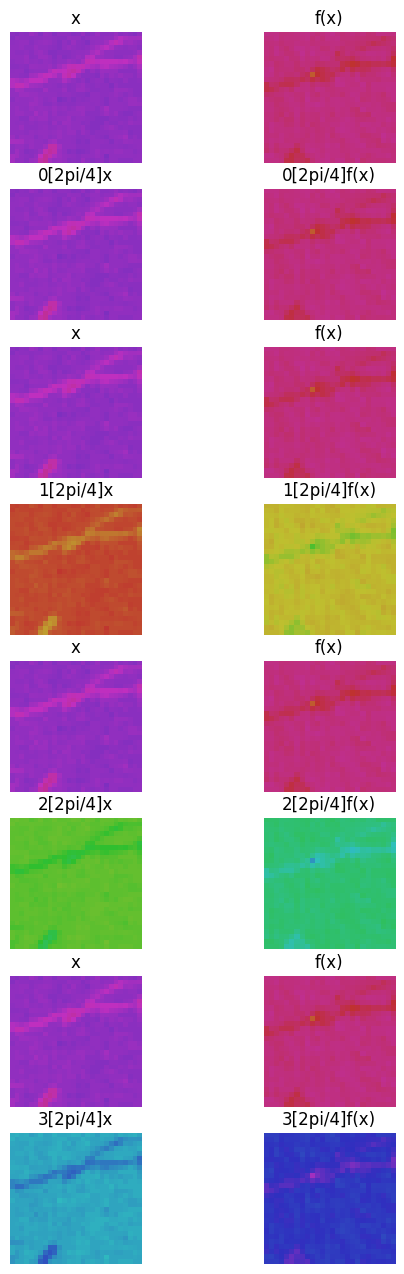

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
with torch.no_grad():
    y = conv(gx) 
transformations = act.fibergroup.elements

fig, ax = plt.subplots(8, 2, figsize=(6, 16))

ax[0, 0].imshow(decode_to_rgb(gx), cmap='gray', vmin=0, vmax=1)

idx = [0, 2, 4, 6]
for i, tr in zip(idx, transformations):
    with torch.no_grad():
        out1 = conv(gx.transform(tr))
        out2 = y.transform(tr)
        print(f"Transform: {tr}, out1 shape: {out1.tensor.shape}, out2 shape: {out2.tensor.shape}")

        err = (out1.tensor - out2.tensor).abs().mean().item()

    print(f"Transform: {tr}, Equivariance MAE: {err:.3e}")

    ax[i, 0].imshow(decode_to_rgb3(gx, s=0.75, v=0.75), cmap='gray', vmin=0, vmax=1)
    ax[i, 0].set_title('x')

    ax[i, 1].imshow(decode_to_rgb3(y, s=0.75, v=0.75), cmap='gray', vmin=0, vmax=1)
    ax[i, 1].set_title('f(x)')

    ax[i+1, 1].imshow(decode_to_rgb3(out2, s=0.75, v=0.75), cmap='gray', vmin=0, vmax=1)
    ax[i+1, 1].set_title(f'{tr}f(x)')

    ax[i+1, 0].imshow(decode_to_rgb3(gx.transform(tr), s=0.75, v=0.75), cmap='gray', vmin=0, vmax=1)
    ax[i+1, 0].set_title(f'{tr}x')

for ax in ax.flatten():
    ax.axis('off')


In [133]:
decode_to_rgb2(gx).shape, gx.shape

((28, 28, 1), torch.Size([1, 2, 28, 28]))

In [141]:
h,w = gx.tensor[0,0,:].shape
print(f"h: {h}, w: {w}")

h: 28, w: 28


Shape gx: torch.Size([1, 2, 28, 28])
Shape y: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 0[2pi/4], Equivariance MAE: 0.000e+00
Transform: 1[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 1[2pi/4], Equivariance MAE: 4.735e-08
Transform: 2[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 2[2pi/4], Equivariance MAE: 1.808e-08
Transform: 3[2pi/4], out1 shape: torch.Size([1, 4, 26, 26]), out2 shape: torch.Size([1, 4, 26, 26])
Transform: 3[2pi/4], Equivariance MAE: 4.735e-08


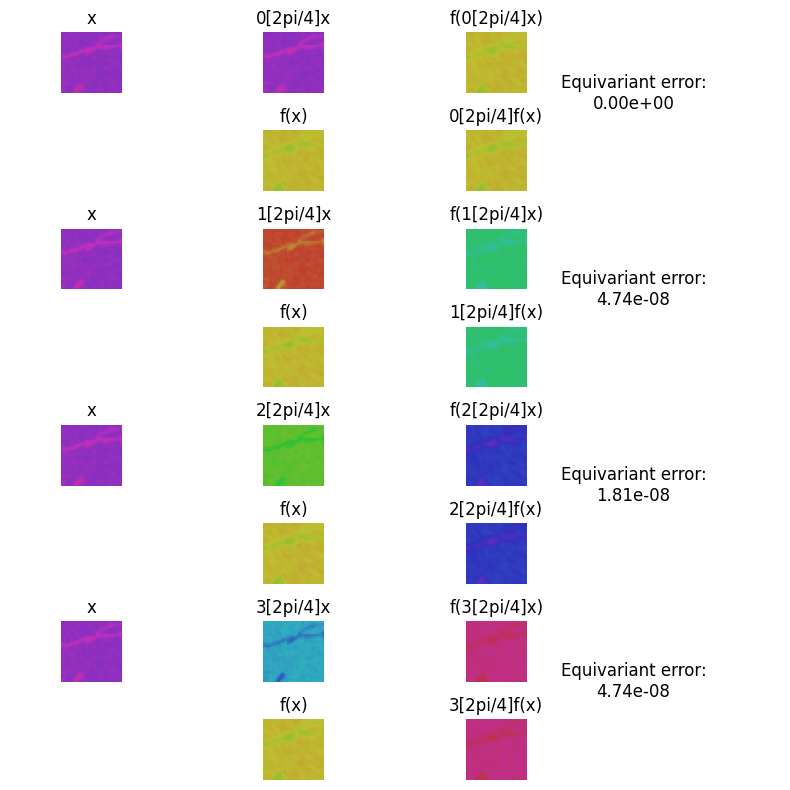

In [157]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]
x = x_hsv.float().clone()
x[0] = torch.remainder(x[0], 1.0)

theta = 2.0 * np.pi * x[0]
x_enc = torch.stack([torch.cos(theta), torch.sin(theta)], dim=0).unsqueeze(0)  # [1,4,H,W]
gx = enn.GeometricTensor(x_enc, in_type)

# ----- group action -----
# g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
with torch.no_grad():
    y = conv(gx) 
transformations = act.fibergroup.elements
print('Shape gx:', gx.tensor.shape)
print('Shape y:', y.tensor.shape)

fig, ax = plt.subplots(8, 4, figsize=(8, 8))

idx = [0, 2, 4, 6]
for i, tr in zip(idx, transformations):
    with torch.no_grad():
        out1 = conv(gx.transform(tr))
        out2 = y.transform(tr)
        print(f"Transform: {tr}, out1 shape: {out1.tensor.shape}, out2 shape: {out2.tensor.shape}")

        err = (out1.tensor - out2.tensor).abs().mean().item()

    print(f"Transform: {tr}, Equivariance MAE: {err:.3e}")

    ax[i, 0].imshow(decode_to_rgb3(gx, s=0.75, v=0.75))
    ax[i, 0].set_title('x')

    ax[i, 1].imshow(decode_to_rgb3(gx.transform(tr), s=0.75, v=0.75))
    ax[i, 1].set_title(f'{tr}x')

    ax[i, 2].imshow(decode_to_rgb3(out1, s=0.75, v=0.75))
    ax[i, 2].set_title(f'f({tr}x)')

    ax[i+1, 1].imshow(decode_to_rgb3(y, s=0.75, v=0.75))
    ax[i+1, 1].set_title(f'f(x)')

    ax[i+1, 2].imshow(decode_to_rgb3(out2, s=0.75, v=0.75))
    ax[i+1, 2].set_title(f'{tr}f(x)')

    ax[i, 3].text(0.1, 0.0, f'Equivariant error:\n{err:.2e}', ha='center', va='center', fontsize=12)


for ax in ax.flatten():
    ax.axis('off')

plt.tight_layout() 

Representation 0 shape: torch.Size([1, 1, 26, 26])
Representation 1 shape: torch.Size([1, 1, 26, 26])
Representation 2 shape: torch.Size([1, 1, 26, 26])
Representation 3 shape: torch.Size([1, 1, 26, 26])
Pairwise representation differences:
[tensor(1.5388e-14), tensor(1.7238e-14), tensor(2.6761e-14), tensor(1.7238e-14), tensor(1.4863e-14), tensor(1.3223e-14)]
Rep 0 vs Rep 1: MSE = 1.539e-14
Rep 0 vs Rep 2: MSE = 1.724e-14
Rep 0 vs Rep 3: MSE = 2.676e-14
Rep 1 vs Rep 2: MSE = 1.486e-14
Rep 1 vs Rep 3: MSE = 1.322e-14


IndexError: list index out of range

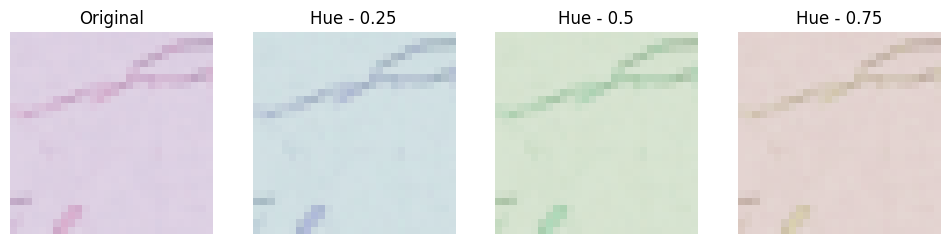

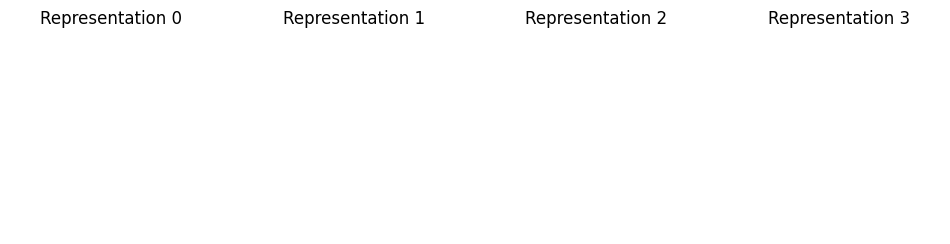

In [33]:
x_hsv2 = x_hsv.clone()
x_hsv2[0, :, :] = torch.remainder(x_hsv[0, :, :] - 0.25, 1.0)
x_hsv3 = x_hsv.clone()
x_hsv3[0, :, :] = torch.remainder(x_hsv[0, :, :] - 0.5, 1.0)
x_hsv4 = x_hsv.clone()
x_hsv4[0, :, :] = torch.remainder(x_hsv[0, :, :] - 0.75, 1.0)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))

x_rgb = hsv_to_rgb(x_hsv.permute(1, 2, 0))
x_rgb2 = hsv_to_rgb(x_hsv2.permute(1, 2, 0))
x_rgb3 = hsv_to_rgb(x_hsv3.permute(1, 2, 0))
x_rgb4 = hsv_to_rgb(x_hsv4.permute(1, 2, 0))

ax[0].imshow(x_rgb)
ax[0].set_title("Original")
ax[1].imshow(x_rgb2)
ax[1].set_title("Hue - 0.25")
ax[2].imshow(x_rgb3)
ax[2].set_title("Hue - 0.5")
ax[3].imshow(x_rgb4)
ax[3].set_title("Hue - 0.75")

for a in ax:
    a.axis("off")

# ----- setup -----
H = 4
act = gspaces.hueOnR2(H)

# input type: [phase_repr, trivial, trivial] = [cos,sin,s,v]
in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])

# output type: 1 regular field -> H channels (one per group element)
out_type = enn.FieldType(act, [act.regular_repr])

conv = enn.R2Conv(in_type, out_type, kernel_size=3, padding=0, bias=False)
gpool = enn.GroupPooling(out_type)

# ----- encode x_hsv -> phase channels -----
# x_hsv: [3, Himg, Wimg], hue in [0,1]

reprs = []
for x in [x_hsv, x_hsv2, x_hsv3, x_hsv4]:
    x = x.float().clone()
    x[0] = torch.remainder(x[0], 1.0)

    theta = 2.0 * np.pi * x[0]
    x_enc = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)  # [1,4,H,W]
    gx = enn.GeometricTensor(x_enc, in_type)

    # ----- group action -----
    # g = act.fibergroup.element(1)  # +1 hue step (90 deg for H=4)
    with torch.no_grad():
        y = conv(gx)
        y = gpool(y)
        reprs.append(y.tensor)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))

for i, y in enumerate(reprs):
    print(f"Representation {i} shape: {y.shape}")
    ax[i].imshow(y.squeeze(0,1), cmap='gray', vmin=0, vmax=1)
    ax[i].set_title(f"Representation {i}")
    ax[i].axis("off")

# compute differences
diffs = []
for i in range(len(reprs)):
    for j in range(i + 1, len(reprs)):
        diff = torch.mean((reprs[i] - reprs[j]) ** 2)
        diffs.append(diff)

print("Pairwise representation differences:")
print(diffs)
for i in range(len(reprs)):
    for j in range(i + 1, len(reprs)):
        print(f"Rep {i} vs Rep {j}: MSE = {diffs[i * len(reprs) + j - (i + 1)].item():.3e}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-52755553000000.0..0.92105263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.5410117e-13..0.89411765].


0: False
1: False
2: False
3: False


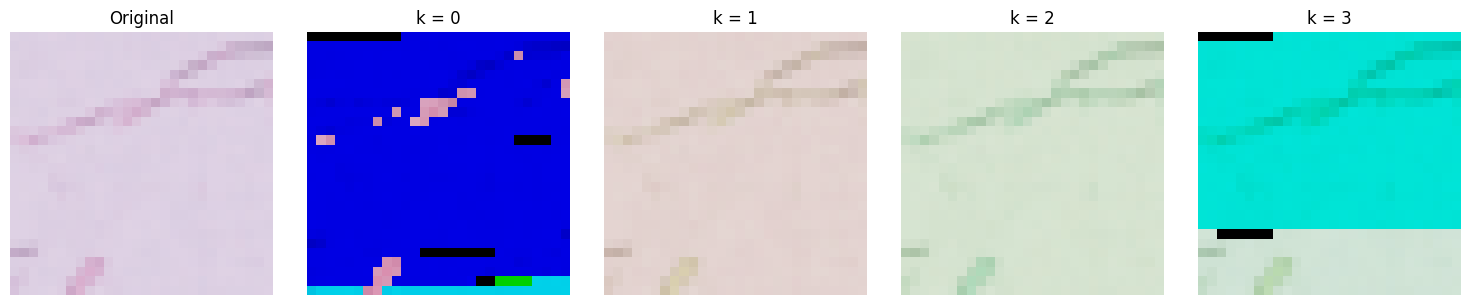

In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from escnn import gspaces
import escnn.nn as enn

# x_hsv must be [3, H, W], hue in [0,1]
x = x_hsv.detach().float().cpu().clone()
# x[0] = torch.remainder(x[0], 1.0)
# x[1:] = x[1:].clamp(0.0, 1.0)

H_group = 4
act = gspaces.hueOnR2(H_group)  # hue-only group C4 on R2 (no spatial action)

# Encode hue as phase [cos(2πh), sin(2πh)] + keep S,V
theta = 2.0 * np.pi * x[0]
x_phase = torch.stack([torch.cos(theta), torch.sin(theta), x[1], x[2]], dim=0).unsqueeze(0)

in_type = enn.FieldType(act, [act.phase_repr, act.trivial_repr, act.trivial_repr])
gx = enn.GeometricTensor(x_phase, in_type)

def decode_to_rgb(gxk):
    p = gxk.tensor[0, 0:2]  # cos,sin
    h = torch.atan2(p[1], p[0]) / (2.0 * np.pi)
    s = gxk.tensor[0, 2]
    v = gxk.tensor[0, 3]
    hsv = torch.stack([h, s, v], dim=-1).numpy()
    return hsv_to_rgb(hsv)

# Plot original + all 4 group elements
fig, ax = plt.subplots(1, H_group + 1, figsize=(3 * (H_group + 1), 3))

ax[0].imshow(hsv_to_rgb(x.permute(1, 2, 0).numpy()))
ax[0].set_title("Original")
ax[0].axis("off")

for k in range(H_group):
    gk = act.fibergroup.element(k)
    gxk = gx.transform(gk)
    ax[k + 1].imshow(decode_to_rgb(gxk))
    ax[k + 1].set_title(f"k = {k}")
    ax[k + 1].axis("off")
    print(f'{k}: {np.allclose(hsv_to_rgb(x.permute(1, 2, 0).numpy()), decode_to_rgb(gxk))}')

plt.tight_layout()
plt.show()


In [7]:
r2_act = gspaces.rot2dOnR2(4)
x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)
out_type = enn.FieldType(r2_act, [r2_act.regular_repr])
lift = enn.R2Conv(in_type, out_type, kernel_size=3)

x_lift = lift(x_g)
print(x_lift.shape)

{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}
torch.Size([1, 4, 26, 26])


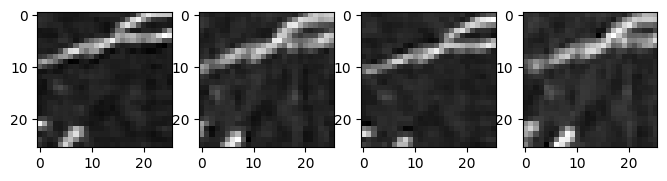

In [52]:
fig, ax = plt.subplots(1, 4, figsize=(8, 4))
for i in range(4):
    b = x_lift.tensor[0,i,:,:]
    ax[i].imshow(b.detach().numpy(), cmap='gray')

In [ ]:
x_t = x_g.transform(r2_act.fibergroup.element(1))


In [22]:
a = x_t.tensor.squeeze(0)
print(a.shape)

torch.Size([3, 28, 28])


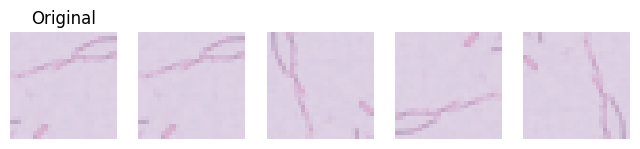

In [8]:
fig, ax = plt.subplots(1, 5, figsize=(8, 4))
ax[0].imshow(x.permute(1, 2, 0))
ax[0].set_title("Original")

for i in range(4):
    x_t = x_g.transform(r2_act.fibergroup.element(i))
    a = x_t.tensor.squeeze(0)

    ax[i+1].imshow(a.squeeze(0).permute(1, 2, 0))

for a in ax:    
    a.axis('off')

In [ ]:
r2_act = gspaces.trivialOnR2()
x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)

[0[2pi/1]]

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(8, 4))
ax[0].imshow(x.permute(1, 2, 0))
ax[0].set_title("Original")

for i in range(4):
    x_t = x_g.transform(r2_act.fibergroup.element(i))
    a = x_t.tensor.squeeze(0)

    ax[i+1].imshow(a.squeeze(0).permute(1, 2, 0))

for a in ax:    
    a.axis('off')

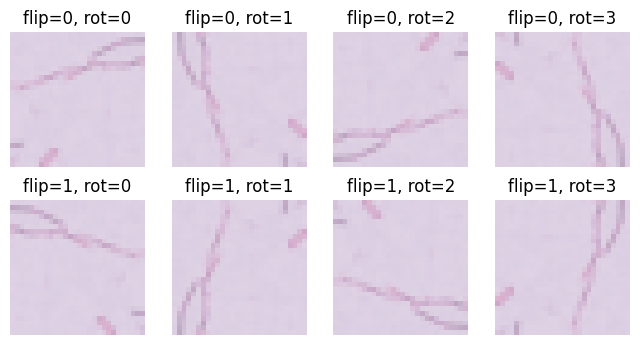

In [62]:
fig, ax = plt.subplots(2, 4, figsize=(8, 4))
# ax[0].imshow(x.permute(1, 2, 0))
# ax[0].set_title("Original")

r2_act = gspaces.flipRot2dOnR2(4)
x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)

for flip in [0, 1]:
    for rot in range(4):
        x_t = x_g.transform(r2_act.fibergroup.element((flip, rot)))
        a = x_t.tensor.squeeze(0)

        ax[flip, rot].imshow(a.squeeze(0).permute(1, 2, 0))
        ax[flip, rot].set_title(f"flip={flip}, rot={rot}")

for a in ax.flatten():  
    a.axis('off')

{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}


Text(0.5, 1.0, 'Transformed')

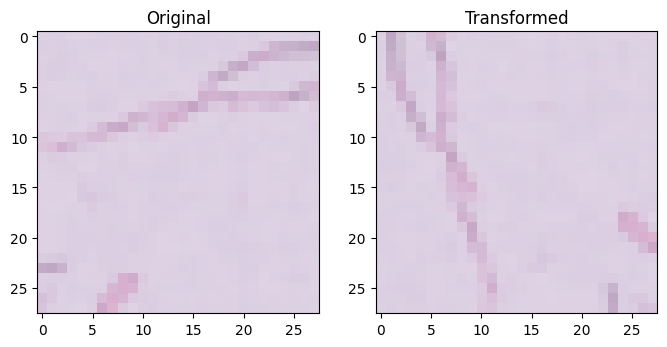

In [17]:
cg = group.CyclicGroup(4)
r2_act = gspaces.rot2dOnR2(4)

x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)

x_tr = x_g.transform(cg.element(1))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(x.permute(1, 2, 0))
ax[0].set_title("Original")
ax[1].imshow(x_tr.tensor.squeeze(0).permute(1, 2, 0))
ax[1].set_title("Transformed")

In [21]:
import numpy as np

In [ ]:
cg = group.CyclicGroup(4)
r2_act = gspaces.rot2dOnR2(4)
test_array = torch.tensor([[ [ [1, 2], [3,4] ]]], dtype=torch.float)  # shape (1, 1, 1, 2)
# x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act,  [r2_act.trivial_repr])
test_gt = enn.GeometricTensor(test_array, in_type)

{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}


In [28]:
print(test_gt)
x_tr = test_gt.transform(cg.element(1))
print(x_tr)


g_tensor([[[[1., 2.],
            [3., 4.]]]], [C4_on_R2[(None, 4)]: {irrep_0 (x1)}(1)])
g_tensor([[[[2., 4.],
            [1., 3.]]]], [C4_on_R2[(None, 4)]: {irrep_0 (x1)}(1)])


In [ ]:
cg = group.CyclicGroup(4)
r2_act = gspaces.rotHueOnR2(1, 4)
test_array = torch.tensor([[ [ [1, 2], [3,4] ]]], dtype=torch.float)
in_type = enn.FieldType(r2_act,  [r2_act.trivial_repr])
test_gt = enn.GeometricTensor(test_array, in_type)
x_tr = test_gt.transform(cg.element(1))


{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}
g_tensor([[[[1., 2.],
            [3., 4.]]]], [C4_on_R2[rotHueOnR2(N=1, H=4)]: {irrep_0 (x1)}(1)])
g_tensor([[[[1., 2.],
            [3., 4.]]]], [C4_on_R2[rotHueOnR2(N=1, H=4)]: {irrep_0 (x1)}(1)])


In [32]:
r2_act = gspaces.rotHueOnR2(N=1, H=4)
x_g = x_hsv.unsqueeze(0)
x_g = enn.GeometricTensor(x_g, enn.FieldType(r2_act, 3 * [r2_act.trivial_repr]))

In [31]:
r2_act = gspaces.rotHueOnR2(N=1, H=4)

x = torch.zeros(1, 4, 2, 2)   # 4 hue bins
x[:, 0] = torch.tensor([[1., 2.], [3., 4.]])  # put content in bin 0

in_type = enn.FieldType(r2_act, [r2_act.regular_repr])
gt = enn.GeometricTensor(x, in_type)

x_tr = gt.transform(r2_act.fibergroup.element(1))

print(gt.tensor.shape, x_tr.tensor.shape)  # spatial shape unchanged
print(gt.tensor[0, :, 0, 0], "->", x_tr.tensor[0, :, 0, 0])  # channels cyclically shift


torch.Size([1, 4, 2, 2]) torch.Size([1, 4, 2, 2])
tensor([1., 0., 0., 0.]) -> tensor([ 5.5511e-17,  1.0000e+00,  5.5511e-17, -5.5511e-17])


In [36]:
print(x[0, :, 1, 0])

tensor([3., 0., 0., 0.])


In [39]:
r2_act = gspaces.rotHueOnR2(N=1, H=4)

x = torch.zeros(1, 4, 2, 2)   # 4 hue bins
x[:, 0] = torch.tensor([[1., 2.], [3., 4.]])  # put content in bin 0

in_type = enn.FieldType(r2_act, [r2_act.regular_repr])
gt = enn.GeometricTensor(x, in_type)

conv = enn.R2Conv(in_type, in_type, kernel_size=1)
x_conv = conv(gt)
print(x_conv.shape)

for i in range(4):
    print(f"Hue bin {i}:")
    print(x_conv.tensor[0,i, :, :])

torch.Size([1, 4, 2, 2])
Hue bin 0:
tensor([[-0.3578, -0.7156],
        [-1.0734, -1.4312]], grad_fn=<SelectBackward0>)
Hue bin 1:
tensor([[-0.7546, -1.5092],
        [-2.2638, -3.0183]], grad_fn=<SelectBackward0>)
Hue bin 2:
tensor([[-0.0970, -0.1940],
        [-0.2909, -0.3879]], grad_fn=<SelectBackward0>)
Hue bin 3:
tensor([[0.7775, 1.5549],
        [2.3324, 3.1099]], grad_fn=<SelectBackward0>)


In [41]:
import torch
from escnn import gspaces
import escnn.nn as enn

def hue_to_soft_bins(h, K):
    # h: [B,1,H,W] in [0,1)
    x = (h % 1.0) * K
    i0 = torch.floor(x).long() % K
    i1 = (i0 + 1) % K
    w1 = x - torch.floor(x)
    w0 = 1.0 - w1

    bins = torch.zeros(h.shape[0], K, h.shape[2], h.shape[3], dtype=h.dtype, device=h.device)
    bins.scatter_add_(1, i0, w0)
    bins.scatter_add_(1, i1, w1)
    return bins

# toy HSV image [B,3,H,W]
hsv = torch.tensor([[
    [[0.05, 0.30], [0.55, 0.90]],  # H
    [[0.80, 0.80], [0.80, 0.80]],  # S
    [[0.90, 0.90], [0.90, 0.90]],  # V
]], dtype=torch.float32)

K = 4
r2_act = gspaces.rotHueOnR2(N=1, H=K)  # hue-only group C4
in_type = enn.FieldType(r2_act, [r2_act.regular_repr, r2_act.trivial_repr, r2_act.trivial_repr])

h, s, v = hsv[:, 0:1], hsv[:, 1:2], hsv[:, 2:3]
h_bins = hue_to_soft_bins(h, K)          # [B,4,H,W]
x = torch.cat([h_bins, s, v], dim=1)     # [B,6,H,W]
print(x)
gx = enn.GeometricTensor(x, in_type)

g1 = r2_act.fibergroup.element(1)        # hue shift by 1 step
y = gx.transform(g1).tensor

print("shape:", y.shape)                  # [1,6,2,2]
print("S unchanged:", torch.allclose(y[:, 4:5], s, atol=1e-6))
print("V unchanged:", torch.allclose(y[:, 5:6], v, atol=1e-6))
print("Hue channels before @ (0,0):", x[0, :4, 0, 0])
print("Hue channels after  @ (0,0):", y[0, :4, 0, 0])


tensor([[[[0.8000, 0.0000],
          [0.0000, 0.6000]],

         [[0.2000, 0.8000],
          [0.0000, 0.0000]],

         [[0.0000, 0.2000],
          [0.8000, 0.0000]],

         [[0.0000, 0.0000],
          [0.2000, 0.4000]],

         [[0.8000, 0.8000],
          [0.8000, 0.8000]],

         [[0.9000, 0.9000],
          [0.9000, 0.9000]]]])
shape: torch.Size([1, 6, 2, 2])
S unchanged: True
V unchanged: True
Hue channels before @ (0,0): tensor([0.8000, 0.2000, 0.0000, 0.0000])
Hue channels after  @ (0,0): tensor([ 3.3307e-17,  8.0000e-01,  2.0000e-01, -3.3307e-17])


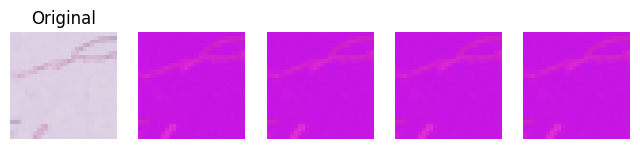

In [33]:
fig, ax = plt.subplots(1, 5, figsize=(8, 4))
ax[0].imshow(x.permute(1, 2, 0))
ax[0].set_title("Original")

for i in range(4):
    x_t = x_g.transform(r2_act.fibergroup.element(i))
    a = x_t.tensor.squeeze(0)

    ax[i+1].imshow(a.squeeze(0).permute(1, 2, 0))

for a in ax:    
    a.axis('off')

In [ ]:
r2_act = gspaces.rotHueOnR2(N=2, H=4)
x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)

fig, ax = plt.subplots(2, 4, figsize=(8, 4))
for rot in [0, 1]:
    for hue in range(4):
        x_t = x_g.transform(r2_act.fibergroup.element((rot, hue)))
        a = x_t.tensor.squeeze(0)

        ax[rot, hue].imshow(a.squeeze(0).permute(1, 2, 0))
        ax[rot, hue].set_title(f"rot={rot}, hue={hue}")

for a in ax.flatten():  
    a.axis('off')

AssertionError: Error! The size of the tensor torch.Size([1, 3, 28, 28]) does not match the size of the field type 8.

torch.Size([1, 4, 26, 26])


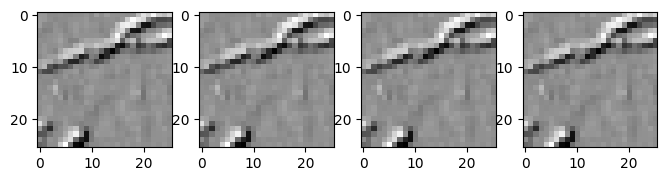

In [46]:
r2_act = gspaces.rotHueOnR2(N=1, H=4)
x_g = x.unsqueeze(0)
in_type = enn.FieldType(r2_act, 3 * [r2_act.trivial_repr])
x_g = enn.GeometricTensor(x_g, in_type)
out_type = enn.FieldType(r2_act, [r2_act.regular_repr])
lift = enn.R2Conv(in_type, out_type, kernel_size=3)

x_lift = lift(x_g)
print(x_lift.shape)

fig, ax = plt.subplots(1, 4, figsize=(8, 4))
for i in range(4):
    b = x_lift.tensor[0,i,:,:]
    ax[i].imshow(b.detach().numpy(), cmap='gray')

In [72]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from escnn import gspaces
import escnn.nn as enn

# ---------- helpers ----------
def encode_rgb_to_huebins(rgb_chw, K):
    # rgb_chw: [3,H,W] in [0,1]
    hsv = rgb_to_hsv(rgb_chw.permute(1, 2, 0).cpu().numpy())
    hue = torch.from_numpy(hsv[..., 0]).float()
    sat = torch.from_numpy(hsv[..., 1]).float()
    val = torch.from_numpy(hsv[..., 2]).float()

    idx = torch.floor(hue * K).long() % K
    bins = torch.zeros(1, K, hue.shape[0], hue.shape[1], dtype=torch.float32)
    bins.scatter_(1, idx[None, None], torch.ones(1, 1, hue.shape[0], hue.shape[1]))
    return bins, sat, val

def decode_huebins_to_rgb(bins_khw, sat, val, K):
    hue = bins_khw.argmax(dim=0).float() / K
    hsv = np.stack([hue.numpy(), sat.numpy(), val.numpy()], axis=-1)
    return hsv_to_rgb(hsv)

# # ---------- synthetic RGB image with clear hue structure ----------
# H, W = 120, 240
# hue = np.tile(np.linspace(0, 1, W, endpoint=False), (H, 1))
# sat = np.ones((H, W), dtype=np.float32) * 0.95
# val = np.ones((H, W), dtype=np.float32) * 0.95
# rgb0 = torch.from_numpy(hsv_to_rgb(np.stack([hue, sat, val], axis=-1))).permute(2, 0, 1).float()

# ---------- hue group only ----------
K = 4
r2_act = gspaces.rotHueOnR2(N=1, H=K)  # N=1 => no spatial rotation, only hue group C_K
ft = enn.FieldType(r2_act, [r2_act.regular_repr])  # IMPORTANT: non-trivial hue action

gx = enn.GeometricTensor(x_hsv.unsqueeze(0), ft)

# ---------- apply hue shifts and plot ----------
fig, ax = plt.subplots(1, K + 1, figsize=(3*(K + 1), 3))
ax[0].imshow(x.permute(1, 2, 0).numpy())
ax[0].set_title("Original RGB")
ax[0].axis("off")

for k in range(K):
    gk = r2_act.fibergroup.element(k)      # for N=1 use integer hue step
    gxk = gx.transform(gk)                 # hue shift in representation space
    rgbk = gxk.tensor[0].permute(1, 2, 0).numpy()  # directly decode RGB from transformed tensor
    rgbk = hsv_to_rgb(rgbk)  # convert back to RGB for visualization
    ax[k + 1].imshow(rgbk)
    ax[k + 1].set_title(f"Hue + {k*360//K}°")
    ax[k + 1].axis("off")

plt.tight_layout()
plt.show()


AssertionError: Error! The size of the tensor torch.Size([1, 3, 28, 28]) does not match the size of the field type 4.

max abs diff to direct hue shift: 1.1920928955078125e-07


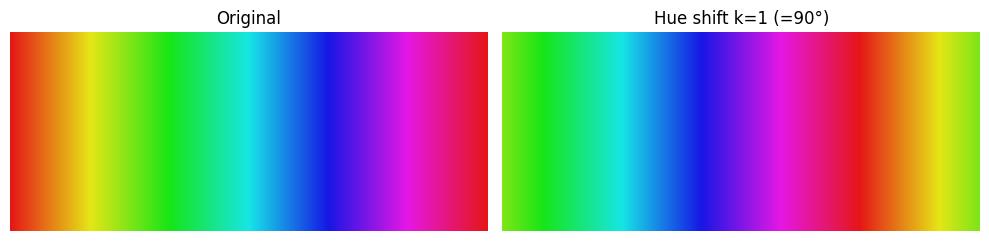

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# ----- synthetic HSV image -----
H, W = 100, 240
h = torch.linspace(0, 1, W).repeat(H, 1)          # hue in [0,1)
s = torch.ones_like(h) * 0.9
v = torch.ones_like(h) * 0.9

# Encode hue: h -> [cos(2pi h), sin(2pi h)]
theta = 2 * np.pi * h
uv = torch.stack([torch.cos(theta), torch.sin(theta)], dim=0)  # [2,H,W]

# ----- choose discrete hue group C_N -----
N = 4
k = 1
alpha = 2 * np.pi * k / N

R = torch.tensor([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
], dtype=torch.float32)

# Apply group action in feature space
uv_shift = torch.einsum("ij,jhw->ihw", R, uv)

# Decode back to hue
h_from_uv = (torch.atan2(uv_shift[1], uv_shift[0]) / (2 * np.pi)) % 1.0
h_direct = (h + k / N) % 1.0

print("max abs diff to direct hue shift:", (h_from_uv - h_direct).abs().max().item())

# Keep S,V unchanged
rgb0 = hsv_to_rgb(np.stack([h.numpy(), s.numpy(), v.numpy()], axis=-1))
rgb1 = hsv_to_rgb(np.stack([h_from_uv.numpy(), s.numpy(), v.numpy()], axis=-1))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(rgb0); ax[0].set_title("Original")
ax[1].imshow(rgb1); ax[1].set_title(f"Hue shift k={k} (={360*k//N}°)")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()
